In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy import stats
from xgboost import XGBRegressor
import lightgbm as lgb
import joblib, os, json, time, re, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#333333",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "savefig.bbox": "tight",
})

PALETTE = {
    "primary": "#2c7fb8",
    "accent":  "#e6550d",
    "success": "#31a354",
    "danger":  "#d62728",
    "warning": "#fec44f",
    "neutral": "#636363",
    "purple":  "#756bb1",
}

FIG_DIR   = Path("../figures/regression")
MODEL_DIR = Path("../models")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

FIG_N = 1  # reset for new figure sequence

def save_fig(stem):
    global FIG_N
    plt.savefig(FIG_DIR / f"{FIG_N:02d}_{stem}.png", dpi=150, bbox_inches="tight")
    FIG_N += 1

print("Setup complete.")

Setup complete.


In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
val   = pd.read_parquet("../data/processed/val.parquet")
test  = pd.read_parquet("../data/processed/test.parquet")

with open("../models/feature_cols.json") as f:
    meta = json.load(f)
feature_cols = meta["features"]
target_col   = meta["target"]

print(f"Train: {train.shape}  Val: {val.shape}  Test: {test.shape}")
print(f"Features: {len(feature_cols)}  Target base: {target_col}")

Train: (34541, 48)  Val: (7402, 48)  Test: (7402, 48)
Features: 39  Target base: avg_return_temp


In [3]:
def add_regression_target(df, target_col="avg_return_temp"):
    df = df.copy()
    df["y_next"] = df[target_col].shift(-1)
    return df.dropna(subset=["y_next"])

train_r = add_regression_target(train)
val_r   = add_regression_target(val)
test_r  = add_regression_target(test)

print(f"Train: {len(train_r):,}  Val: {len(val_r):,}  Test: {len(test_r):,}")
print(f"y_next range (train): {train_r['y_next'].min():.2f} – {train_r['y_next'].max():.2f} °C")
print(f"y_next mean ± std   : {train_r['y_next'].mean():.2f} ± {train_r['y_next'].std():.2f} °C")

Train: 34,540  Val: 7,401  Test: 7,401
y_next range (train): 7.65 – 45.62 °C
y_next mean ± std   : 31.01 ± 4.78 °C


In [4]:
SPLITS = {"train": train_r, "val": val_r, "test": test_r}

def get_ts(d):
    if isinstance(d.index, pd.DatetimeIndex): return d.index
    for c in ("timestamp", "datetime", "time"):
        if c in d.columns: return pd.DatetimeIndex(pd.to_datetime(d[c]))
    return None

def recover_affine():
    u = train["avg_return_temp"].astype(float)
    if 10 < u.mean() < 50 and u.std() > 0.3:
        return 1.0, 0.0, "parquet column already in degC"
    for c in ("avg_return_temp_C", "avg_return_temp_raw"):
        if c in train.columns:
            a, b = np.polyfit(u, train[c].astype(float), 1)
            return float(a), float(b), f"fit against saved column {c}"
    try:
        sc = joblib.load(MODEL_DIR / "scaler.pkl")
        names = list(getattr(sc, "feature_names_in_", []))
        if "avg_return_temp" in names:
            i = names.index("avg_return_temp")
            return float(sc.scale_[i]), float(sc.mean_[i]), "original scaler.pkl"
    except Exception as e:
        print("scaler route failed:", repr(e))
    raise RuntimeError("Cannot recover degC.")

A_C, B_C, HOW = recover_affine()
to_C = lambda u: A_C * np.asarray(u, dtype=float) + B_C
T_now = {k: to_C(d["avg_return_temp"].values) for k, d in SPLITS.items()}
T_nxt = {k: to_C(d["y_next"].values) for k, d in SPLITS.items()}
print(f"degC recovery: {HOW}  (a={A_C:.5f}, b={B_C:.5f})")

for k, d in SPLITS.items():
    assert np.isfinite(T_now[k]).all() and np.isfinite(T_nxt[k]).all()
    gap = np.abs(T_now[k][1:] - T_nxt[k][:-1])
    print(f"{k:5s} next[t] vs now[t+1]: max {gap.max():.6f} °C, rows off >0.01: {(gap > 0.01).sum()}")

for k, d in SPLITS.items():
    ts = get_ts(d)
    if ts is None: continue
    print(f"{k:5s} {ts.min():%Y-%m-%d} -> {ts.max():%Y-%m-%d}  rows {len(d):>6,}")

def day_ids(d):
    ts = get_ts(d)
    return np.arange(len(d)) // 144 if ts is None else pd.factorize(ts.normalize())[0]

DAY = {k: day_ids(d) for k, d in SPLITS.items()}
IDX_A = np.flatnonzero(DAY["val"] % 2 == 0)   # even days: early stopping + ablation
IDX_B = np.flatnonzero(DAY["val"] % 2 == 1)   # odd days: model selection
print(f"val rows: A={len(IDX_A)}  B={len(IDX_B)}")

degC recovery: parquet column already in degC  (a=1.00000, b=0.00000)
train next[t] vs now[t+1]: max 0.000000 °C, rows off >0.01: 0
val   next[t] vs now[t+1]: max 0.000000 °C, rows off >0.01: 0
test  next[t] vs now[t+1]: max 0.000000 °C, rows off >0.01: 0
train 2023-01-01 -> 2023-09-19  rows 34,540
val   2023-09-19 -> 2023-11-10  rows  7,401
test  2023-11-10 -> 2023-12-31  rows  7,401
val rows: A=3659  B=3742


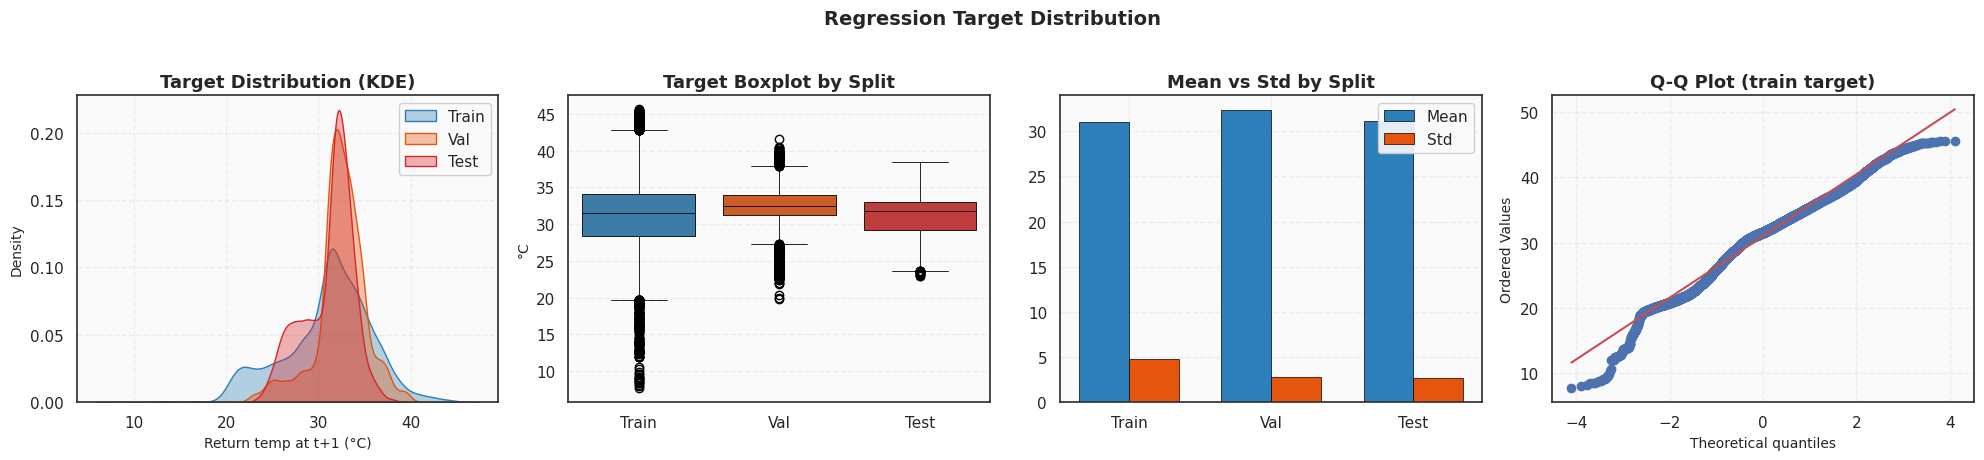

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for name, d, c in [("Train", train_r, PALETTE["primary"]),
                   ("Val",   val_r,   PALETTE["accent"]),
                   ("Test",  test_r,  PALETTE["danger"])]:
    sns.kdeplot(d["y_next"], ax=axes[0], fill=True, alpha=0.35, color=c, label=name)
axes[0].set_title("Target Distribution (KDE)")
axes[0].set_xlabel("Return temp at t+1 (°C)")
axes[0].legend()

box_data = pd.DataFrame({
    "Train": train_r["y_next"], "Val": val_r["y_next"], "Test": test_r["y_next"]
})
sns.boxplot(data=box_data, ax=axes[1],
            palette=[PALETTE["primary"], PALETTE["accent"], PALETTE["danger"]],
            linecolor="black", linewidth=0.6)
axes[1].set_title("Target Boxplot by Split")
axes[1].set_ylabel("°C")

stats_df = pd.DataFrame({
    "split": ["Train", "Val", "Test"],
    "mean":  [train_r["y_next"].mean(), val_r["y_next"].mean(), test_r["y_next"].mean()],
    "std":   [train_r["y_next"].std(),  val_r["y_next"].std(),  test_r["y_next"].std()],
})
x = np.arange(3); w = 0.35
axes[2].bar(x - w/2, stats_df["mean"], w, label="Mean",
            color=PALETTE["primary"], edgecolor="black", linewidth=0.5)
axes[2].bar(x + w/2, stats_df["std"],  w, label="Std",
            color=PALETTE["accent"], edgecolor="black", linewidth=0.5)
axes[2].set_xticks(x); axes[2].set_xticklabels(stats_df["split"])
axes[2].set_title("Mean vs Std by Split")
axes[2].legend()

stats.probplot(train_r["y_next"], dist="norm", plot=axes[3])
axes[3].set_title("Q-Q Plot (train target)")

plt.suptitle("Regression Target Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("target_distribution")
plt.show()

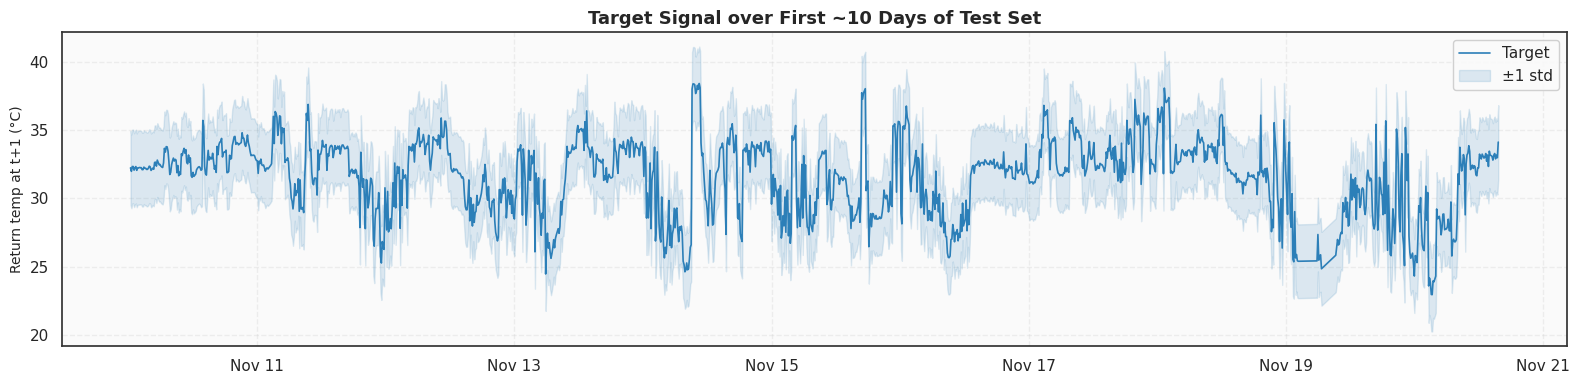

In [6]:
fig, ax = plt.subplots(figsize=(16, 4))
zoom = test_r.iloc[:1500]

ax.plot(zoom["timestamp"], zoom["y_next"], lw=1.2,
        color=PALETTE["primary"], label="Target")
ax.fill_between(zoom["timestamp"],
                zoom["y_next"] - zoom["y_next"].std(),
                zoom["y_next"] + zoom["y_next"].std(),
                alpha=0.15, color=PALETTE["primary"], label="±1 std")

ax.set_title("Target Signal over First ~10 Days of Test Set")
ax.set_ylabel("Return temp at t+1 (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend()
plt.tight_layout()
save_fig("target_over_time")
plt.show()

In [7]:
FEAT_BASE = [c for c in feature_cols if c != "avg_return_temp"]
feature_cols = FEAT_BASE + ["avg_return_temp"]
X_train, X_val, X_test = (d[feature_cols] for d in (train_r, val_r, test_r))
y_train, y_val, y_test = (d["y_next"].values for d in (train_r, val_r, test_r))

regressors, train_s = {}, {}

def fit_timed(name, m, **kw):
    t0 = time.time()
    m.fit(X_train, y_train, **kw)
    train_s[name] = time.time() - t0
    regressors[name] = m

fit_timed("LinearRegression", make_pipeline(StandardScaler(), LinearRegression()))
fit_timed("Ridge",            make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42)))
fit_timed("RandomForest",     RandomForestRegressor(
    n_estimators=300, min_samples_leaf=10, n_jobs=-1, random_state=42))
fit_timed("XGBoost",          XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    tree_method="hist", n_jobs=-1, random_state=42))
fit_timed("LightGBM",         lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    min_child_samples=50, subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8, reg_lambda=5.0, random_state=42,
    n_jobs=-1, verbose=-1, deterministic=True, force_row_wise=True))

print("Feature set size:", len(feature_cols))
print("Training times (s):", {k: round(v, 1) for k, v in train_s.items()})

Feature set size: 40
Training times (s): {'LinearRegression': 0.1, 'Ridge': 0.1, 'RandomForest': 42.6, 'XGBoost': 6.9, 'LightGBM': 5.3}


In [8]:
def reg_scores(y, pred):
    return dict(
        MAE=mean_absolute_error(y, pred),
        RMSE=np.sqrt(mean_squared_error(y, pred)),
        R2=r2_score(y, pred),
        MAPE=np.mean(np.abs((y - pred) / y)) * 100,
    )

prev = lambda x: np.r_[x[:1], x[:-1]]

BASE_PRED = {
    "persistence":       T_now["test"],
    "linear trend":      T_now["test"] + (T_now["test"] - prev(T_now["test"])),
    "last 3 mean":       (T_now["test"] + prev(T_now["test"]) + prev(prev(T_now["test"]))) / 3,
}
BASE_SCORE = {k: v for k, v in BASE_PRED.items()}

base_tbl = pd.DataFrame({k: reg_scores(T_nxt["test"], v) for k, v in BASE_PRED.items()}).T
print("=== Baselines (test set) ===")
print(base_tbl.round(4))

d_te = T_nxt["test"] - T_now["test"]
print(f"\n|ΔT| test percentiles 50/90/99 (°C): {np.round(np.percentile(np.abs(d_te), [50, 90, 99]), 3)}")

=== Baselines (test set) ===
                 MAE    RMSE      R2    MAPE
persistence   0.8218  1.4332  0.7261  2.6835
linear trend  1.3515  2.2787  0.3076  4.4186
last 3 mean   0.8781  1.4497  0.7198  2.8732

|ΔT| test percentiles 50/90/99 (°C): [0.39  2.061 5.892]


In [9]:
ANNUAL  = re.compile(r"(month|doy|day_?of_?year|week_?of_?year|season|quarter)", re.I)
DIURNAL = re.compile(r"(hour|minute|dow|day_?of_?week|weekday|weekend|_sin$|_cos$|^sin_|^cos_)", re.I)
annual_cols   = [c for c in FEAT_BASE if ANNUAL.search(c)]
calendar_cols = sorted(set(annual_cols) | {c for c in FEAT_BASE if DIURNAL.search(c)})
print("annual  :", annual_cols)
print("calendar:", calendar_cols)

VARIANTS = {
    "all":         feature_cols,
    "no_annual":   [c for c in feature_cols if c not in annual_cols],
    "no_calendar": [c for c in feature_cols if c not in calendar_cols],
}

# Residual-target: LightGBM predicts ΔT = T(t+1) − T(t)
D = {k: T_nxt[k] - T_now[k] for k in SPLITS}

def fit_delta_lgbm(cols, seed=42, n_estimators=1500):
    reg = lgb.LGBMRegressor(
        n_estimators=n_estimators, learning_rate=0.05, num_leaves=31,
        min_child_samples=50, subsample=0.8, subsample_freq=1,
        colsample_bytree=0.8, reg_lambda=5.0, random_state=seed,
        n_jobs=-1, verbose=-1, deterministic=True, force_row_wise=True,
    )
    reg.fit(X_train[cols].values, D["train"],
            eval_set=[(X_val.iloc[IDX_A][cols].values, D["val"][IDX_A])],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(50, verbose=False)])
    return reg

TA = T_nxt["val"][IDX_A]
mae_pers = np.abs(D["val"][IDX_A]).mean()
abl = {}
for name, cols_ in VARIANTS.items():
    reg_ = fit_delta_lgbm(cols_)
    pred_ = T_now["val"][IDX_A] + reg_.predict(X_val.iloc[IDX_A][cols_].values)
    mae = np.abs(TA - pred_).mean()
    abl[name] = dict(
        n_feat=len(cols_),
        trees=reg_.best_iteration_,
        valA_MAE=mae,
        skill_vs_persist=1 - mae / mae_pers,
        valA_R2=r2_score(TA, pred_),
    )

abl = pd.DataFrame(abl).T
print(abl.round(4))
print(f"persistence MAE on val-A: {mae_pers:.4f} °C")
best = abl.valA_MAE.min()
FINAL_VARIANT = next(v for v in ["no_calendar", "no_annual", "all"]
                     if abl.loc[v, "valA_MAE"] <= 1.03 * best)
print("chosen on val-A only:", FINAL_VARIANT)

annual  : []
calendar: ['dow_cos', 'dow_sin', 'hour_cos', 'hour_sin']
             n_feat  trees  valA_MAE  skill_vs_persist  valA_R2
all            40.0    2.0    0.9299            0.0041   0.6146
no_annual      40.0    2.0    0.9299            0.0041   0.6146
no_calendar    36.0    3.0    0.9310            0.0029   0.6169
persistence MAE on val-A: 0.9337 °C
chosen on val-A only: no_calendar


In [10]:
cols = VARIANTS[FINAL_VARIANT]

# LightGBM on ΔT
t0 = time.time()
lgbm_reg = fit_delta_lgbm(cols)
train_s["ForecastLGBM (dT)"] = time.time() - t0

# XGBoost on ΔT
t0 = time.time()
xgb_reg = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    tree_method="hist", n_jobs=-1, random_state=42,
)
xgb_reg.fit(X_train[cols].values, D["train"],
            eval_set=[(X_val.iloc[IDX_A][cols].values, D["val"][IDX_A])],
            verbose=False)
train_s["ForecastXGB (dT)"] = time.time() - t0

# Compute test predictions
def forecast(reg, cols_):
    return T_now["test"] + reg.predict(X_test[cols_].values)

pred_lgbm = forecast(lgbm_reg, cols)
pred_xgb  = forecast(xgb_reg, cols)

print(f"LightGBM ΔT: best_iter={lgbm_reg.best_iteration_}, "
      f"test MAE={mean_absolute_error(T_nxt['test'], pred_lgbm):.4f} °C, "
      f"R²={r2_score(T_nxt['test'], pred_lgbm):.4f}")
print(f"XGBoost ΔT : test MAE={mean_absolute_error(T_nxt['test'], pred_xgb):.4f} °C, "
      f"R²={r2_score(T_nxt['test'], pred_xgb):.4f}")
print(f"Persistence: test MAE={mean_absolute_error(T_nxt['test'], T_now['test']):.4f} °C, "
      f"R²={r2_score(T_nxt['test'], T_now['test']):.4f}")

LightGBM ΔT: best_iter=3, test MAE=0.8310 °C, R²=0.7389
XGBoost ΔT : test MAE=1.8232 °C, R²=0.0838
Persistence: test MAE=0.8218 °C, R²=0.7261


=== Regression Comparison (test set) ===
                      MAE    RMSE      R2    MAPE  train_s
persistence        0.8218  1.4332  0.7261  2.6835   0.0000
linear trend       1.3515  2.2787  0.3076  4.4186   0.0000
last 3 mean        0.8781  1.4497  0.7198  2.8732   0.0000
LinearRegression   1.1673  1.6652  0.6302  3.7709   0.1297
Ridge              1.1654  1.6612  0.6320  3.7635   0.0585
RandomForest       1.7410  2.4626  0.1913  5.7526  42.6309
XGBoost            1.8283  2.6398  0.0707  5.9831   6.9372
LightGBM           1.7890  2.5949  0.1020  5.8283   5.3127
ForecastLGBM (dT)  0.8310  1.3992  0.7389  2.7170   1.1164
ForecastXGB (dT)   1.8232  2.6212  0.0838  5.9532   4.3332

Best by MAE: persistence


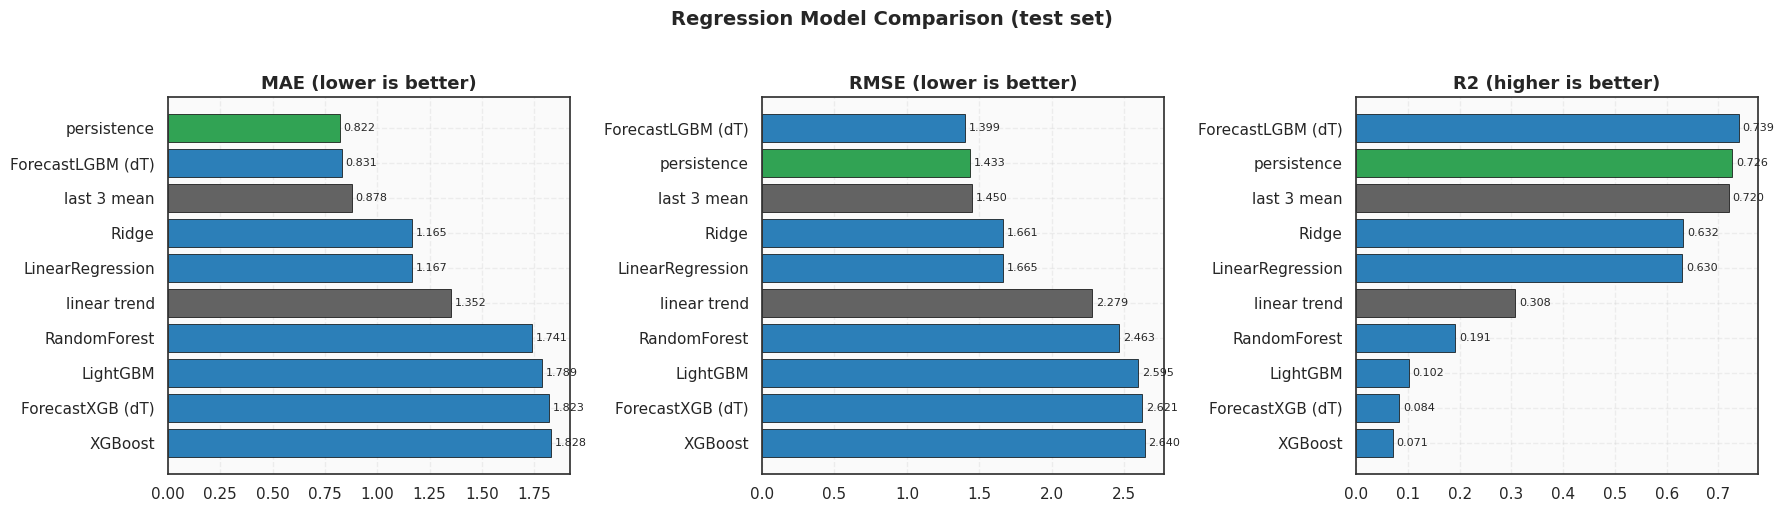

In [11]:
# Absolute-target models (from Cell 7)
ABS_PRED = {n: m.predict(X_test) for n, m in regressors.items()}
ABS_SCORE = {n: reg_scores(T_nxt["test"], v) for n, v in ABS_PRED.items()}

# ΔT models
DELTA_PRED = {
    "ForecastLGBM (dT)": pred_lgbm,
    "ForecastXGB (dT)":  pred_xgb,
}
DELTA_SCORE = {n: reg_scores(T_nxt["test"], v) for n, v in DELTA_PRED.items()}

# Merge all
ALL_PRED = {**BASE_PRED, **ABS_PRED, **DELTA_PRED}
cmp_tbl = pd.DataFrame(
    {n: reg_scores(T_nxt["test"], p) for n, p in ALL_PRED.items()}
).T

# Add training time
cmp_tbl["train_s"] = [0.0 if n in BASE_PRED else train_s.get(n, np.nan)
                       for n in cmp_tbl.index]

print("=== Regression Comparison (test set) ===")
print(cmp_tbl.round(4).to_string())

best_reg = cmp_tbl["MAE"].idxmin()
print(f"\nBest by MAE: {best_reg}")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, better in zip(axes, ["MAE", "RMSE", "R2"], ["lower", "lower", "higher"]):
    vals = cmp_tbl[metric].sort_values(ascending=(better == "lower"))
    colors = [PALETTE["success"] if idx == best_reg
              else PALETTE["neutral"] if idx in BASE_PRED
              else PALETTE["primary"]
              for idx in vals.index]
    ax.barh(vals.index, vals.values, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(f"{metric} ({better} is better)")
    ax.invert_yaxis()
    for i, v in enumerate(vals.values):
        ax.text(v + max(vals.values) * 0.01, i, f"{v:.3f}", va="center", fontsize=8)

plt.suptitle("Regression Model Comparison (test set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("model_comparison")
plt.show()

In [12]:
DAYS_T = DAY["test"]
UD = np.unique(DAYS_T)
BY_DAY = {d: np.flatnonzero(DAYS_T == d) for d in UD}

def boot_ci(fn, y, p, n_boot=300, seed=42):
    rng, out = np.random.default_rng(seed), []
    for _ in range(n_boot):
        idx = np.concatenate([BY_DAY[d] for d in rng.choice(UD, len(UD))])
        out.append(fn(y[idx], p[idx]))
    return np.nanpercentile(out, [2.5, 97.5])

def mae_fn(y, p): return mean_absolute_error(y, p)
def r2_fn(y, p):  return r2_score(y, p)

y_true = T_nxt["test"]
rows = []
for name, p in ALL_PRED.items():
    lo, hi = boot_ci(mae_fn, y_true, p)
    lo2, hi2 = boot_ci(r2_fn, y_true, p)
    rows.append({
        "model": name,
        "MAE": mean_absolute_error(y_true, p),
        "MAE_CI95": f"[{lo:.3f}, {hi:.3f}]",
        "R2": r2_score(y_true, p),
        "R2_CI95": f"[{lo2:.3f}, {hi2:.3f}]",
    })

ci_tbl = pd.DataFrame(rows).set_index("model")
print("=== Bootstrap CIs (day-block, 300 resamples) ===")
print(ci_tbl.round(4).to_string())

=== Bootstrap CIs (day-block, 300 resamples) ===
                      MAE        MAE_CI95      R2          R2_CI95
model                                                             
persistence        0.8218  [0.721, 0.915]  0.7261   [0.657, 0.777]
linear trend       1.3515  [1.197, 1.505]  0.3076   [0.119, 0.440]
last 3 mean        0.8781  [0.772, 0.985]  0.7198   [0.652, 0.770]
LinearRegression   1.1673  [1.069, 1.262]  0.6302   [0.539, 0.694]
Ridge              1.1654  [1.067, 1.260]  0.6320   [0.541, 0.695]
RandomForest       1.7410  [1.496, 1.956]  0.1913   [0.036, 0.317]
XGBoost            1.8283  [1.596, 2.069]  0.0707  [-0.140, 0.236]
LightGBM           1.7890  [1.558, 2.022]  0.1020  [-0.113, 0.259]
ForecastLGBM (dT)  0.8310  [0.735, 0.920]  0.7389   [0.674, 0.786]
ForecastXGB (dT)   1.8232  [1.595, 2.040]  0.0838  [-0.120, 0.256]


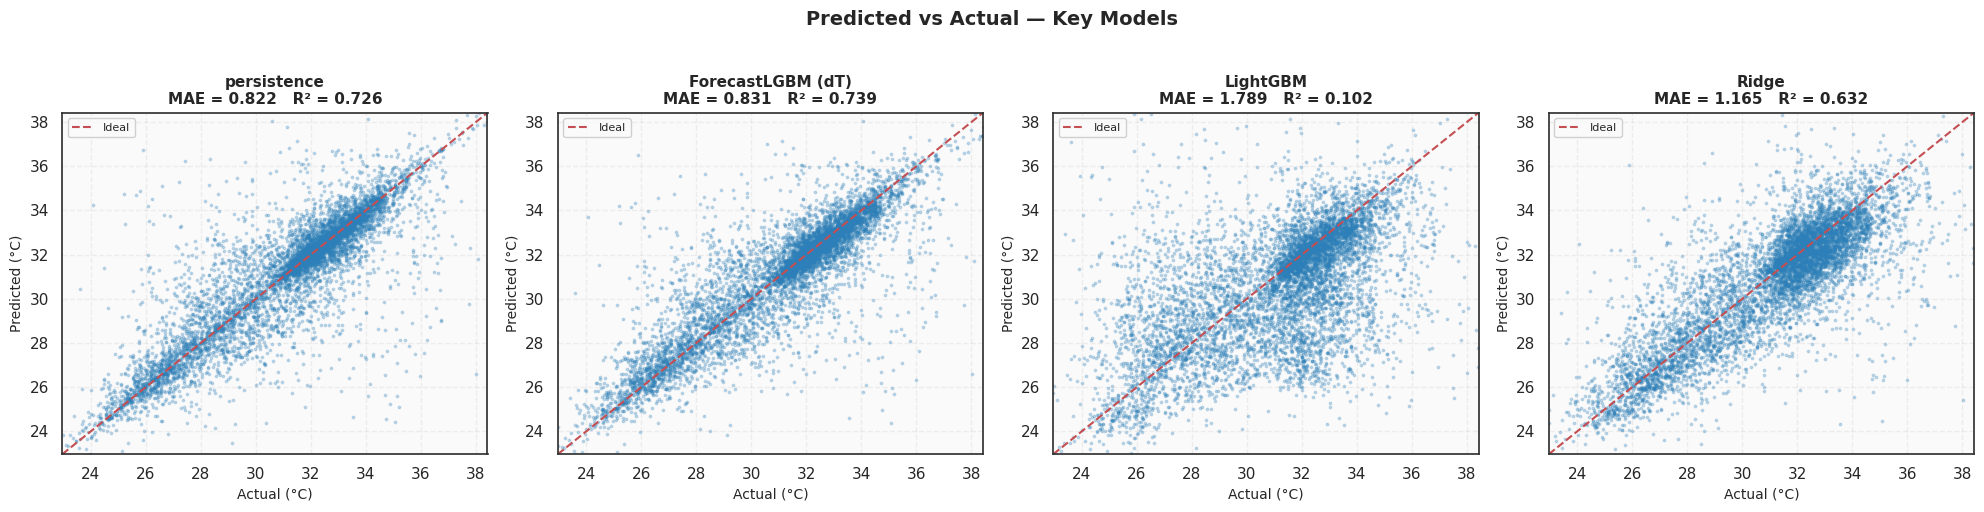

In [13]:
preds_show = ["persistence", "ForecastLGBM (dT)", "LightGBM", "Ridge"]
preds_show = [p for p in preds_show if p in ALL_PRED]

fig, axes = plt.subplots(1, len(preds_show), figsize=(5 * len(preds_show), 5))
if len(preds_show) == 1: axes = [axes]

lims = [y_true.min(), y_true.max()]
for ax, name in zip(axes, preds_show):
    p = ALL_PRED[name]
    ax.scatter(y_true, p, s=3, alpha=0.25, color=PALETTE["primary"])
    ax.plot(lims, lims, "r--", lw=1.5, label="Ideal")
    ax.set_xlabel("Actual (°C)")
    ax.set_ylabel("Predicted (°C)")
    ax.set_title(f"{name}\nMAE = {mean_absolute_error(y_true, p):.3f}   R² = {r2_score(y_true, p):.3f}",
                 fontsize=11)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend(loc="upper left", fontsize=8)

plt.suptitle("Predicted vs Actual — Key Models", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("pred_vs_actual")
plt.show()

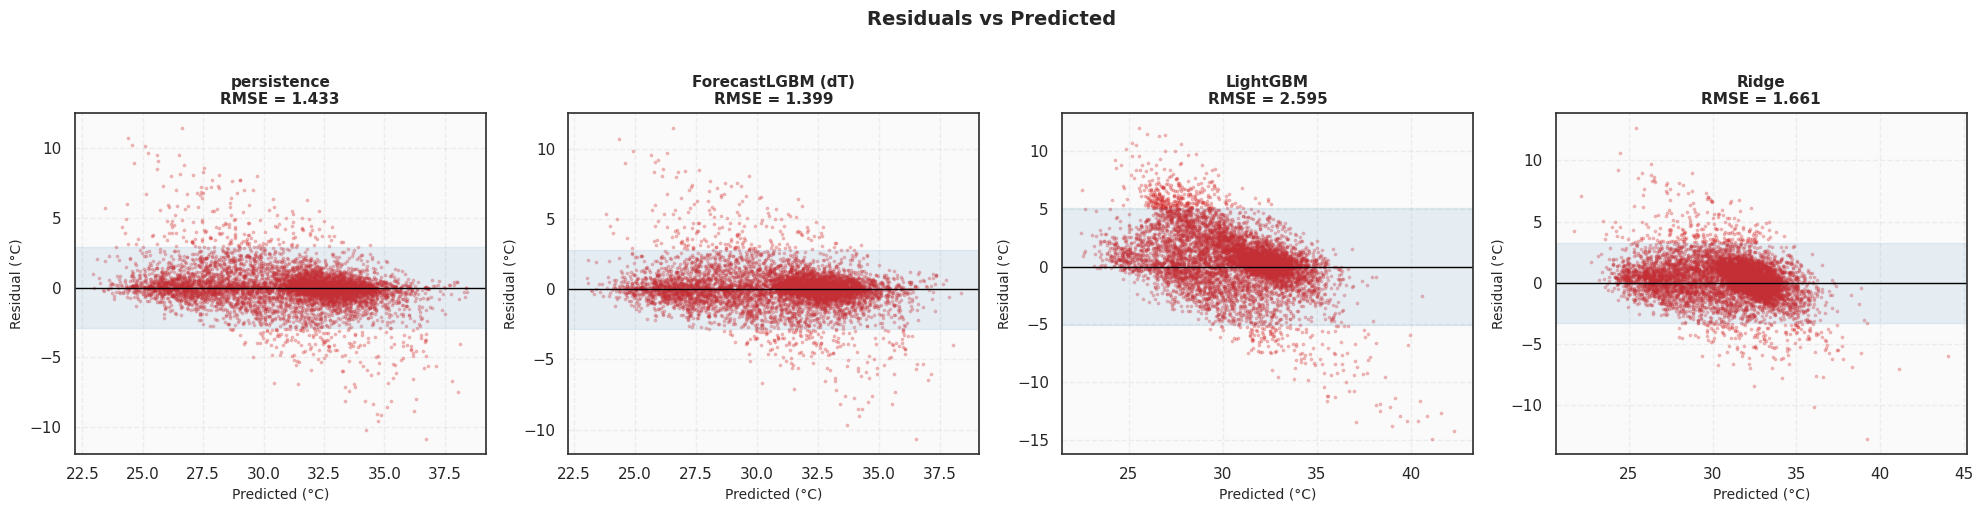

In [14]:
fig, axes = plt.subplots(1, len(preds_show), figsize=(5 * len(preds_show), 5))
if len(preds_show) == 1: axes = [axes]

for ax, name in zip(axes, preds_show):
    p = ALL_PRED[name]
    r = y_true - p
    ax.scatter(p, r, s=3, alpha=0.25, color=PALETTE["danger"])
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("Predicted (°C)")
    ax.set_ylabel("Residual (°C)")
    ax.set_title(f"{name}\nRMSE = {np.sqrt((r**2).mean()):.3f}", fontsize=11)
    s = r.std()
    ax.axhspan(-2*s, 2*s, alpha=0.1, color=PALETTE["primary"])

plt.suptitle("Residuals vs Predicted", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("residuals_vs_pred")
plt.show()

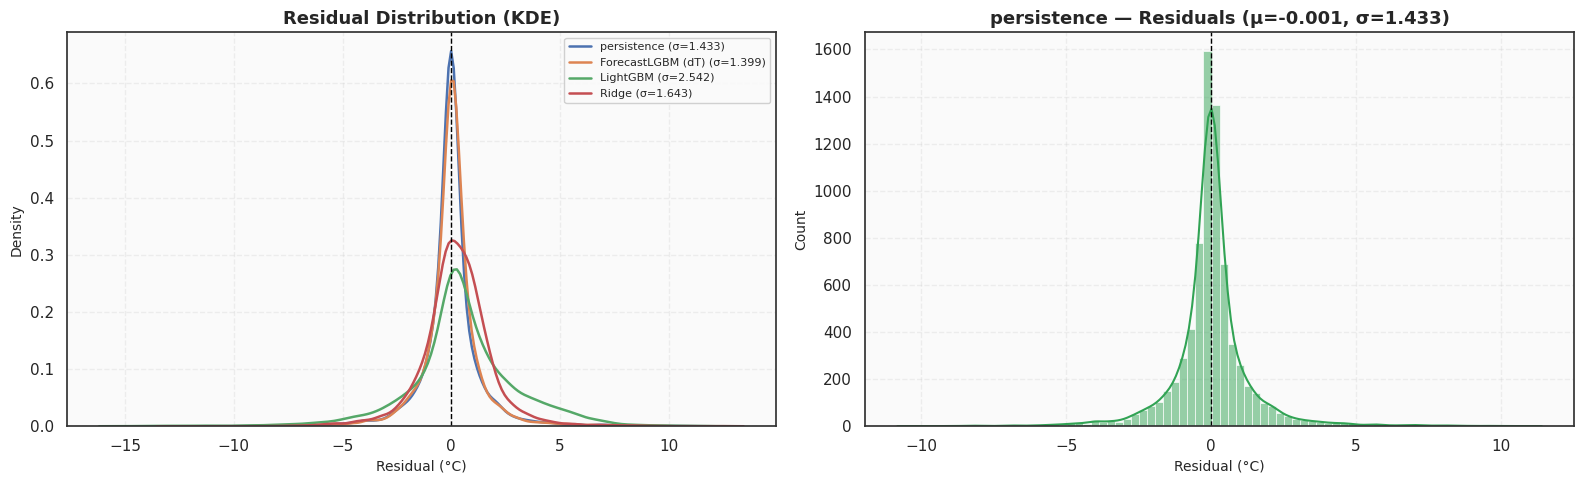

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for name in preds_show:
    r = y_true - ALL_PRED[name]
    sns.kdeplot(r, ax=axes[0], lw=1.8, label=f"{name} (σ={r.std():.3f})")
axes[0].axvline(0, color="black", ls="--", lw=1)
axes[0].set_xlabel("Residual (°C)")
axes[0].set_title("Residual Distribution (KDE)")
axes[0].legend(fontsize=8)

best_res = y_true - ALL_PRED[best_reg]
sns.histplot(best_res, bins=80, kde=True, ax=axes[1],
             color=PALETTE["success"], edgecolor="white")
axes[1].axvline(0, color="black", ls="--", lw=1)
axes[1].set_xlabel("Residual (°C)")
axes[1].set_title(f"{best_reg} — Residuals (μ={best_res.mean():.3f}, σ={best_res.std():.3f})")

plt.tight_layout()
save_fig("residual_distributions")
plt.show()

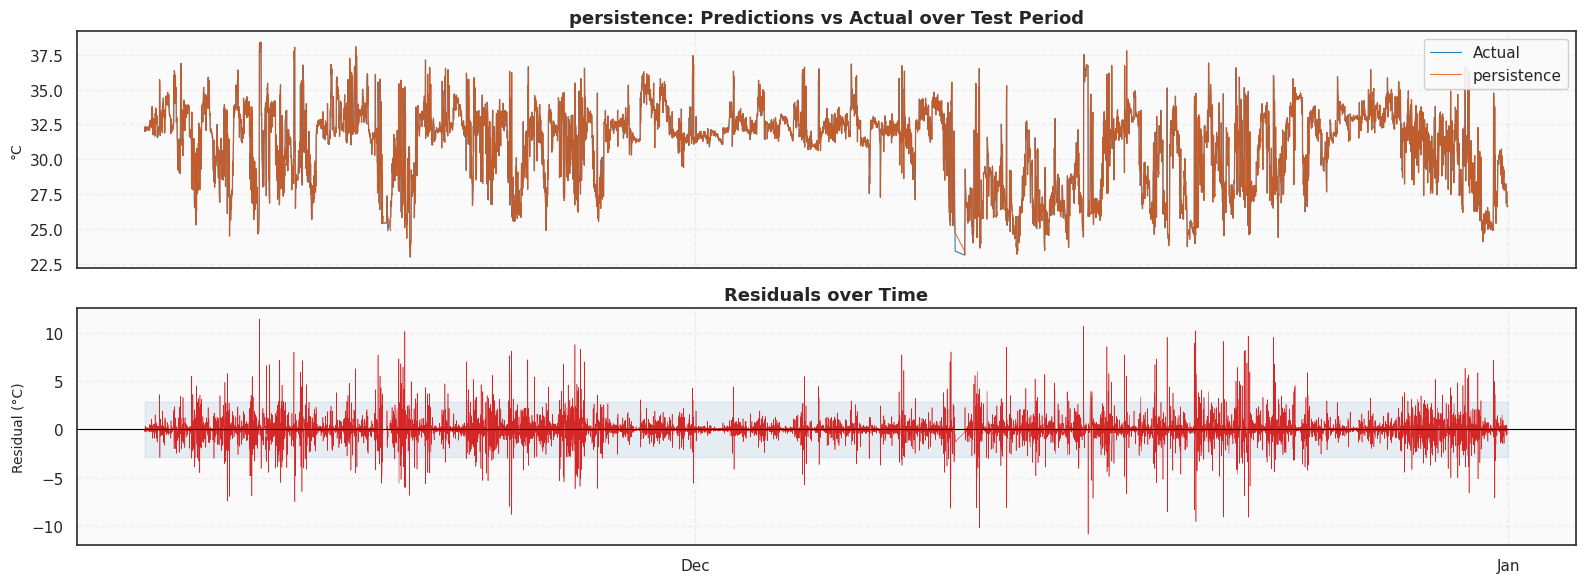

In [16]:
best_pred = ALL_PRED[best_reg]
residuals = y_true - best_pred

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(test_r["timestamp"], y_true, lw=0.8, label="Actual", color=PALETTE["primary"])
axes[0].plot(test_r["timestamp"], best_pred, lw=0.8, alpha=0.8,
             label=f"{best_reg}", color=PALETTE["accent"])
axes[0].set_ylabel("°C")
axes[0].set_title(f"{best_reg}: Predictions vs Actual over Test Period")
axes[0].legend(loc="upper right")

axes[1].plot(test_r["timestamp"], residuals, lw=0.4, color=PALETTE["danger"])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].fill_between(test_r["timestamp"],
                     -residuals.std()*2, residuals.std()*2,
                     alpha=0.1, color=PALETTE["primary"])
axes[1].set_ylabel("Residual (°C)")
axes[1].set_title("Residuals over Time")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
save_fig("error_over_time")
plt.show()

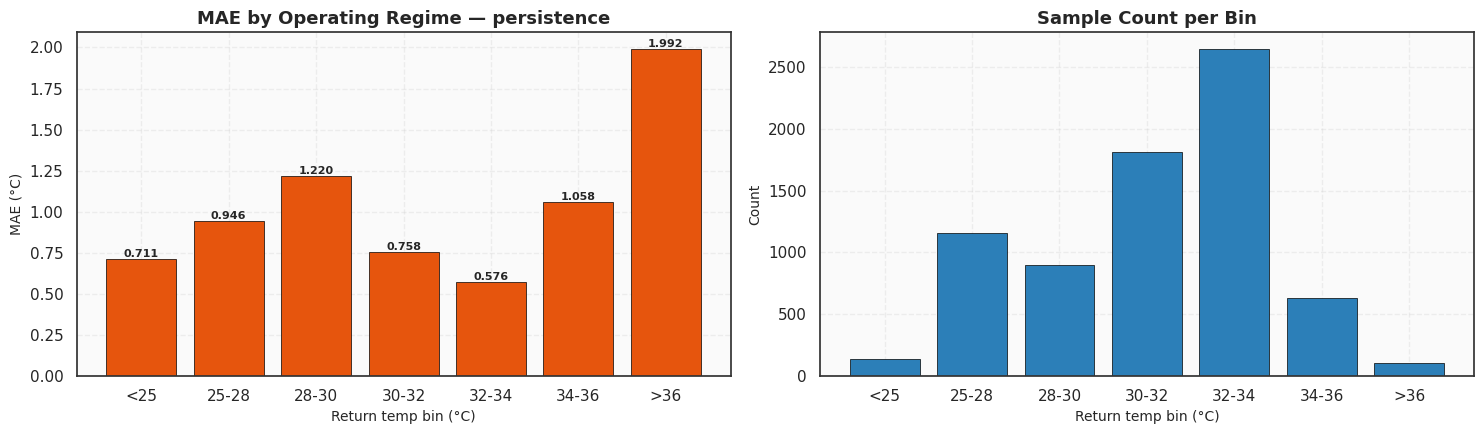

            mae     n
bin                  
<25    0.711247   138
25-28  0.945919  1159
28-30  1.220428   897
30-32  0.758190  1815
32-34  0.575783  2646
34-36  1.058054   635
>36    1.992104   111


In [17]:
test_r_ = test_r.copy()
test_r_["pred"]    = best_pred
test_r_["abs_err"] = np.abs(test_r_["y_next"] - test_r_["pred"])
test_r_["bin"]     = pd.cut(test_r_["y_next"],
                             bins=[0, 25, 28, 30, 32, 34, 36, 100],
                             labels=["<25", "25-28", "28-30", "30-32", "32-34", "34-36", ">36"])

bin_stats = test_r_.groupby("bin", observed=True).agg(
    mae=("abs_err", "mean"),
    n=("abs_err", "size"),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

bars = axes[0].bar(range(len(bin_stats)), bin_stats["mae"],
                    color=PALETTE["accent"], edgecolor="black", linewidth=0.5)
axes[0].set_xticks(range(len(bin_stats)))
axes[0].set_xticklabels(bin_stats.index)
axes[0].set_xlabel("Return temp bin (°C)")
axes[0].set_ylabel("MAE (°C)")
axes[0].set_title(f"MAE by Operating Regime — {best_reg}")
for bar, v in zip(bars, bin_stats["mae"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"{v:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

axes[1].bar(range(len(bin_stats)), bin_stats["n"],
            color=PALETTE["primary"], edgecolor="black", linewidth=0.5)
axes[1].set_xticks(range(len(bin_stats)))
axes[1].set_xticklabels(bin_stats.index)
axes[1].set_xlabel("Return temp bin (°C)")
axes[1].set_ylabel("Count")
axes[1].set_title("Sample Count per Bin")

plt.tight_layout()
save_fig("error_by_regime")
plt.show()

print(bin_stats)

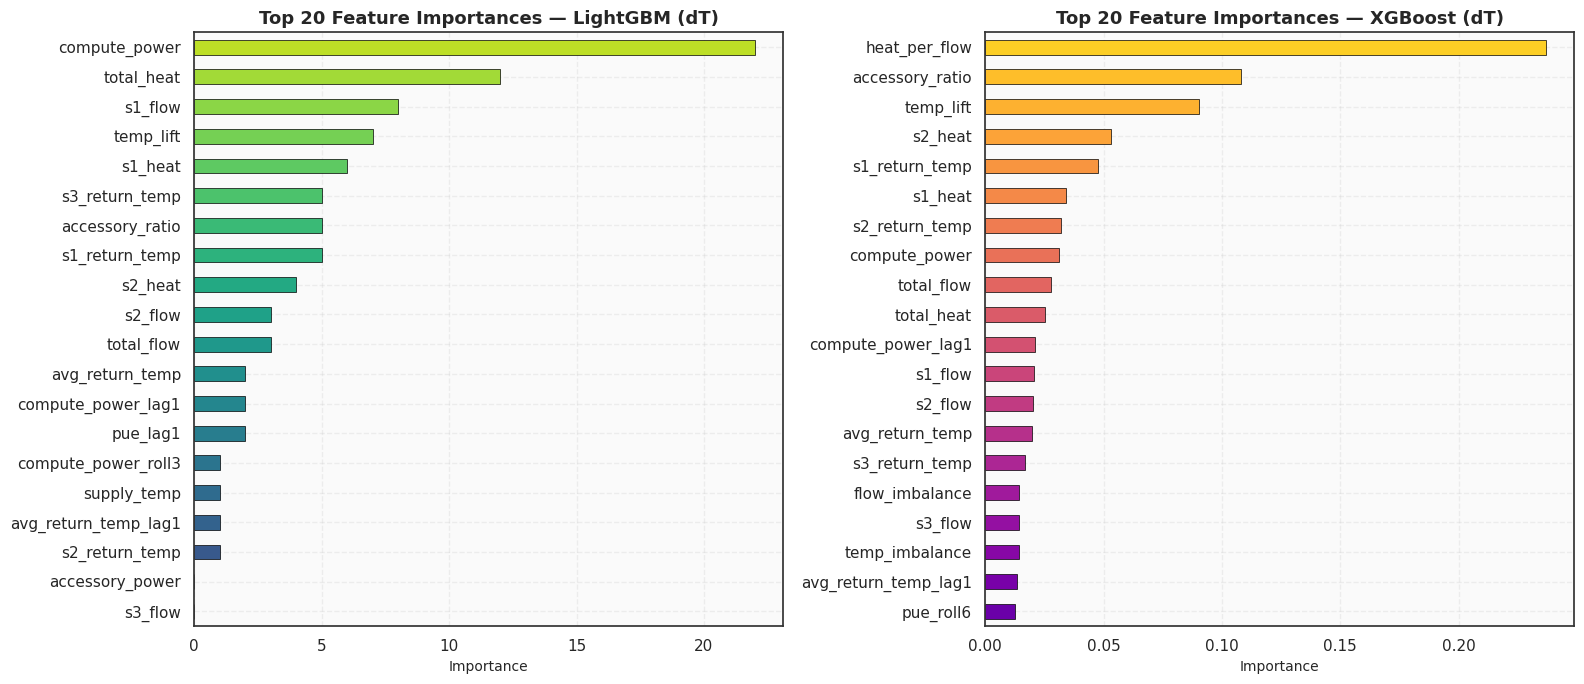

In [18]:
imp_lgbm = pd.Series(lgbm_reg.feature_importances_, index=cols).sort_values(ascending=False).head(20)
imp_xgb  = pd.Series(xgb_reg.feature_importances_,  index=cols).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors1 = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp_lgbm)))[::-1]
imp_lgbm.plot(kind="barh", ax=axes[0], color=colors1, edgecolor="black", linewidth=0.5)
axes[0].invert_yaxis()
axes[0].set_title(f"Top 20 Feature Importances — LightGBM (dT)")
axes[0].set_xlabel("Importance")

colors2 = plt.cm.plasma(np.linspace(0.2, 0.9, len(imp_xgb)))[::-1]
imp_xgb.plot(kind="barh", ax=axes[1], color=colors2, edgecolor="black", linewidth=0.5)
axes[1].invert_yaxis()
axes[1].set_title(f"Top 20 Feature Importances — XGBoost (dT)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
save_fig("feature_importance")
plt.show()

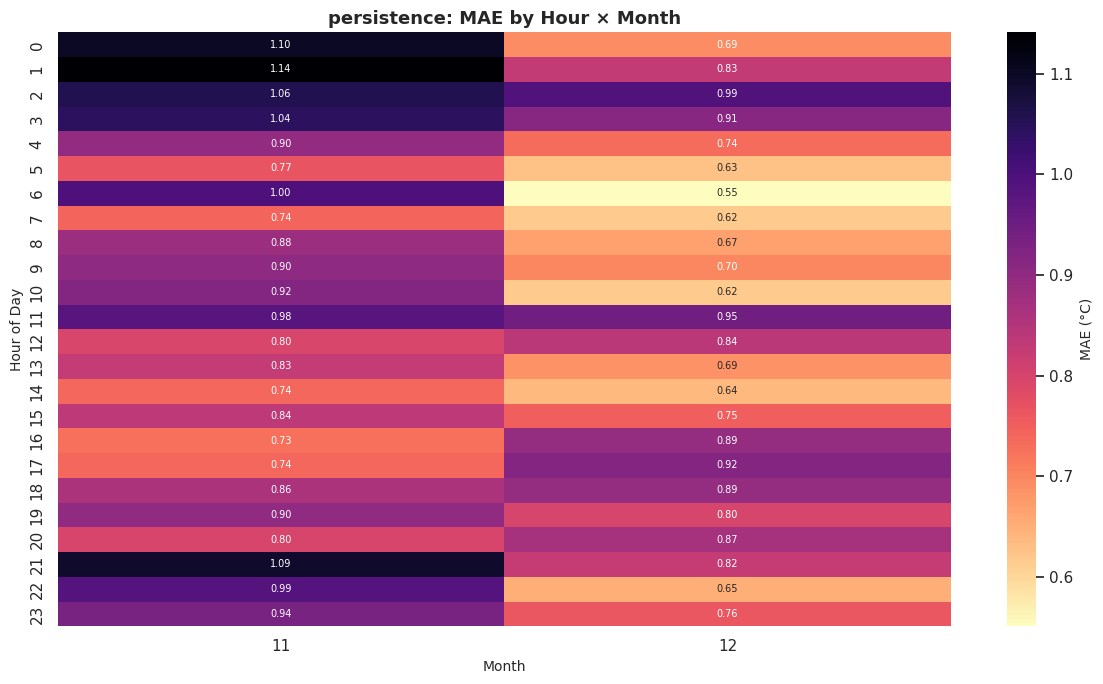

In [19]:
test_r_["hour"]  = test_r_["timestamp"].dt.hour
test_r_["month"] = test_r_["timestamp"].dt.month

pivot = test_r_.pivot_table(index="hour", columns="month",
                             values="abs_err", aggfunc="mean")

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, cmap="magma_r", annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"label": "MAE (°C)"}, ax=ax)
ax.set_title(f"{best_reg}: MAE by Hour × Month", fontsize=13, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Hour of Day")
plt.tight_layout()
save_fig("error_heatmap")
plt.show()

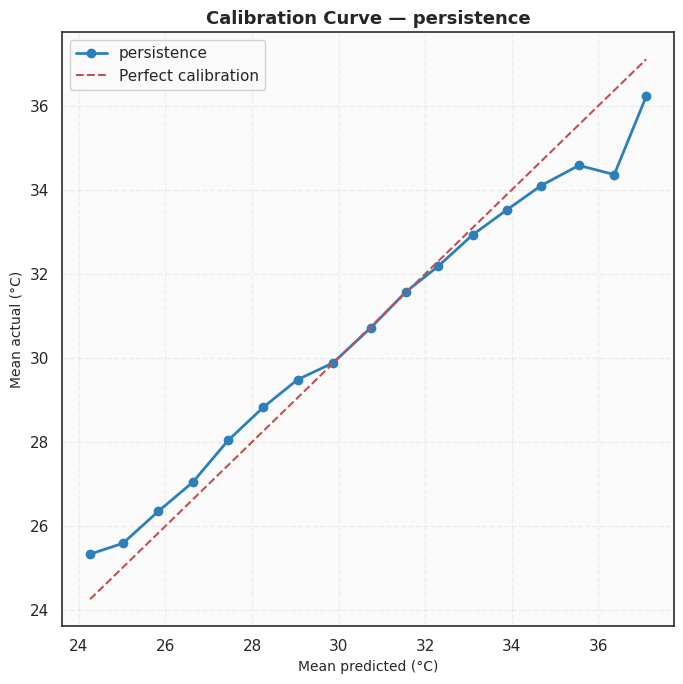

In [20]:
bins = np.linspace(y_true.min(), y_true.max(), 20)
bin_idx = np.digitize(best_pred, bins)

calib_x, calib_y = [], []
for i in range(1, len(bins)):
    mask = bin_idx == i
    if mask.sum() > 20:
        calib_x.append(best_pred[mask].mean())
        calib_y.append(y_true[mask].mean())

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(calib_x, calib_y, "o-", color=PALETTE["primary"], lw=2, ms=6, label=best_reg)
lims = [min(calib_x + calib_y), max(calib_x + calib_y)]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect calibration")
ax.set_xlabel("Mean predicted (°C)")
ax.set_ylabel("Mean actual (°C)")
ax.set_title(f"Calibration Curve — {best_reg}")
ax.legend()
plt.tight_layout()
save_fig("calibration")
plt.show()

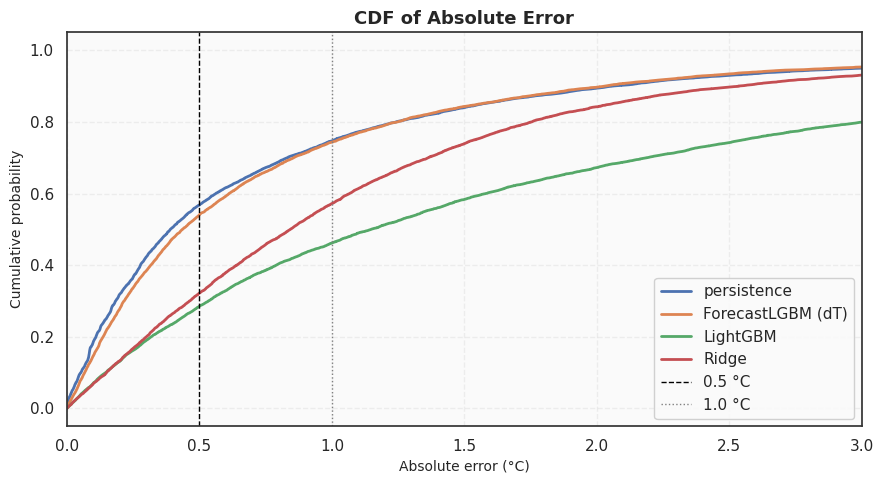

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

for name in preds_show:
    r = np.abs(y_true - ALL_PRED[name])
    s = np.sort(r)
    cdf = np.arange(1, len(s) + 1) / len(s)
    ax.plot(s, cdf, lw=2, label=name)

ax.axvline(0.5, color="black", ls="--", lw=1, label="0.5 °C")
ax.axvline(1.0, color="gray",  ls=":",  lw=1, label="1.0 °C")
ax.set_xlabel("Absolute error (°C)")
ax.set_ylabel("Cumulative probability")
ax.set_title("CDF of Absolute Error")
ax.set_xlim(0, 3)
ax.legend(loc="lower right")
plt.tight_layout()
save_fig("error_cdf")
plt.show()

In [22]:
best_row = cmp_tbl.loc[best_reg]
pers_row = cmp_tbl.loc["persistence"]

card = {
    "target":                          "avg_return_temp @ t+1 (10 min ahead)",
    "split":                           "chronological 70/15/15",
    "features_total":                  len(feature_cols),
    "features_used":                   len(cols),
    "variant":                         FINAL_VARIANT,
    "best_model":                      best_reg,
    "best_MAE (°C)":                   best_row["MAE"],
    "best_RMSE (°C)":                  best_row["RMSE"],
    "best_R²":                         best_row["R2"],
    "best_MAPE (%)":                   best_row["MAPE"],
    "persistence_MAE (°C)":            pers_row["MAE"],
    "persistence_R²":                  pers_row["R2"],
    "skill_vs_persistence (MAE)":      f"{1 - best_row['MAE']/pers_row['MAE']:+.2%}",
    "LGBM_dT_MAE (°C)":                mean_absolute_error(y_true, pred_lgbm),
    "LGBM_dT_R²":                      r2_score(y_true, pred_lgbm),
    "LGBM_best_iteration":             int(lgbm_reg.best_iteration_) if hasattr(lgbm_reg, "best_iteration_") else None,
}

print("=" * 70)
print("COOLANT REGRESSION SUMMARY (test set)")
print("=" * 70)
for k, v in card.items():
    if isinstance(v, float):
        print(f"{k:<32s} {v:.4f}")
    else:
        print(f"{k:<32s} {v}")

json.dump({k: (float(v) if isinstance(v, (float, np.floating)) else v) for k, v in card.items()},
          open(MODEL_DIR / "coolant_regression_summary.json", "w"), indent=2)

COOLANT REGRESSION SUMMARY (test set)
target                           avg_return_temp @ t+1 (10 min ahead)
split                            chronological 70/15/15
features_total                   40
features_used                    36
variant                          no_calendar
best_model                       persistence
best_MAE (°C)                    0.8218
best_RMSE (°C)                   1.4332
best_R²                          0.7261
best_MAPE (%)                    2.6835
persistence_MAE (°C)             0.8218
persistence_R²                   0.7261
skill_vs_persistence (MAE)       +0.00%
LGBM_dT_MAE (°C)                 0.8310
LGBM_dT_R²                       0.7389
LGBM_best_iteration              3


In [23]:
lgbm_reg.booster_.save_model(str(MODEL_DIR / "coolant_regression_lgbm.txt"))
xgb_reg.save_model(str(MODEL_DIR / "coolant_regression_xgb.json"))

meta = dict(
    task="forecast T(t+1) in degC via dT residual",
    variant=FINAL_VARIANT,
    features=cols,
    all_features=feature_cols,
    current_temp_col="avg_return_temp",
    degC_affine=dict(a=A_C, b=B_C, how=HOW),
    lgbm_best_iter=int(lgbm_reg.best_iteration_) if hasattr(lgbm_reg, "best_iteration_") else None,
    seed=42,
    test_metrics=dict(
        MAE=float(mean_absolute_error(y_true, pred_lgbm)),
        RMSE=float(np.sqrt(mean_squared_error(y_true, pred_lgbm))),
        R2=float(r2_score(y_true, pred_lgbm)),
    ),
    versions=dict(lightgbm=lgb.__version__, xgboost=__import__("xgboost").__version__,
                  numpy=np.__version__, pandas=pd.__version__),
)
json.dump(meta, open(MODEL_DIR / "coolant_regression_meta.json", "w"), indent=2, default=str)

bst = lgb.Booster(model_file=str(MODEL_DIR / "coolant_regression_lgbm.txt"))
dmax = np.abs(bst.predict(X_test[cols].values) - lgbm_reg.predict(X_test[cols].values)).max()
print(f"reload check max |diff| = {dmax:.2e}")
assert dmax < 1e-6

print("✓ Saved:")
print(f"   {MODEL_DIR}/coolant_regression_lgbm.txt")
print(f"   {MODEL_DIR}/coolant_regression_xgb.json")
print(f"   {MODEL_DIR}/coolant_regression_meta.json")
print(f"   {MODEL_DIR}/coolant_regression_summary.json")

reload check max |diff| = 0.00e+00
✓ Saved:
   ../models/coolant_regression_lgbm.txt
   ../models/coolant_regression_xgb.json
   ../models/coolant_regression_meta.json
   ../models/coolant_regression_summary.json
